# 1. Imports & Global Settings

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
from itertools import product
from scipy.stats import spearmanr
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, make_scorer,
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso
sns.set(style="whitegrid")
plt.rcParams.update({"figure.figsize": (10, 6), "pdf.fonttype": 42, "ps.fonttype": 42})
warnings.filterwarnings("ignore")

# 2. Configuration & Constants

In [2]:
DATA_PATH = "/home/bateer/Projects/06_Zhangnan_protein_2025/07_Manuscript/02_temp_manuscript/01_manuscript/01_data/Raw/1ezgdata.csv"
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
POSITION_PAIRS = [
    (16, 28), (28, 40), (40, 52), (52, 64),
    (26, 38), (38, 50), (50, 62), (3, 16),
]

# 3. Feature Engineering Functions

In [3]:
def generate_maps(amino_acids):
    all_2mers = ["".join(pair) for pair in product(amino_acids, repeat=2)]
    kmer_to_idx = {kmer: i for i, kmer in enumerate(all_2mers)}
    return all_2mers, kmer_to_idx


def get_2mer_counts(sequence, kmer_to_idx):
    counts = np.zeros(len(kmer_to_idx))
    for i in range(len(sequence) - 1):
        kmer = sequence[i : i + 2]
        if kmer in kmer_to_idx:
            counts[kmer_to_idx[kmer]] += 1
    return counts


def get_position_2mer(sequence, pos1, pos2, kmer_to_idx):
    if pos1 > len(sequence) or pos2 > len(sequence):
        return np.zeros(len(kmer_to_idx))
    kmer = sequence[pos1 - 1] + sequence[pos2 - 1]
    one_hot = np.zeros(len(kmer_to_idx))
    if kmer in kmer_to_idx:
        one_hot[kmer_to_idx[kmer]] = 1
    return one_hot


ALL_2MERS, KMER_TO_IDX = generate_maps(AMINO_ACIDS)

# 4. Data Processing Pipeline
Load CSV → Feature extraction → Top-200 variance filtering → MinMax scaling

In [4]:
def process_data(filepath):
    df = pd.read_csv(filepath)

    # Feature names
    feature_names = [f"{k[0]}_{k[1]}" for k in ALL_2MERS]
    for p1, p2 in POSITION_PAIRS:
        feature_names.extend([f"{k[0]}{p1+1}_{k[1]}{p2+1}" for k in ALL_2MERS])

    # Feature extraction
    all_features = []
    for seq in df["sequence"]:
        global_vec = get_2mer_counts(seq, KMER_TO_IDX)
        pos_vecs = [get_position_2mer(seq, p1, p2, KMER_TO_IDX) for p1, p2 in POSITION_PAIRS]
        all_features.append(np.concatenate([global_vec, np.concatenate(pos_vecs)]))
    X_raw = np.array(all_features)

    # Top 200 variance filtering
    variances = np.var(X_raw, axis=0)
    n_keep = min(200, X_raw.shape[1])
    top_idx = np.sort(np.argsort(variances)[-n_keep:])
    X_filtered = X_raw[:, top_idx]
    final_feature_names = [feature_names[i] for i in top_idx]

    print(f"Original features: {X_raw.shape[1]} → Selected: {X_filtered.shape[1]}")

    # Scaling
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_filtered)

    result_df = pd.concat(
        [df[["protein_name", "activity_score"]].copy(),
         pd.DataFrame(X_scaled, columns=final_feature_names)],
        axis=1,
    )
    return result_df, final_feature_names


processed_df, feature_names = process_data(DATA_PATH)

Original features: 3600 → Selected: 200


# 5. Data Splitting
Train: first 97 samples | Test: last 24 samples

In [5]:
TRAIN_SIZE = 97
TEST_SIZE = 24

df_train = processed_df.iloc[:TRAIN_SIZE].copy()
df_test = processed_df.iloc[-TEST_SIZE:].copy()

X_train_full = df_train[feature_names].values
y_train_full = df_train["activity_score"].values
X_test = df_test[feature_names].values
y_test = df_test["activity_score"].values

print(f"Training: {len(df_train)} | Test: {len(df_test)}")

Training: 97 | Test: 24


# 6. Model Definitions & Metric Function

In [6]:
def calculate_metrics(y_true, y_pred):
    y_true, y_pred = y_true.flatten(), y_pred.flatten()
    spearman = spearmanr(y_true, y_pred)[0] if np.std(y_pred) > 1e-9 else 0.0
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mask = y_true != 0
    mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) if np.any(mask) else 0.0
    return {"Spearman": spearman, "RMSE": rmse, "MAE": mae, "MAPE": mape}


xgb_params = {
    "subsample": 0.7, "n_estimators": 100, "min_child_weight": 1,
    "max_depth": 3, "learning_rate": 0.15, "gamma": 0.0, "colsample_bytree": 0.9,
}

models = {
    "RandomForest": RandomForestRegressor(n_estimators=2, random_state=111),
    "SVR": SVR(kernel="sigmoid", epsilon=0.01, C=0.5),
    "Ridge": Ridge(alpha=0.5),
    "Lasso": Lasso(alpha=0.0001, max_iter=10),
    "XGBoost": xgb.XGBRegressor(random_state=1, **xgb_params),
}

# 7. Cross-Validation & Test Evaluation

In [7]:
kf = KFold(n_splits=10, shuffle=True, random_state=1)
cv_fold_records = []
test_results = {}

for name, model in models.items():
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_full)):
        model.fit(X_train_full[train_idx], y_train_full[train_idx])
        preds = model.predict(X_train_full[val_idx])
        for metric, value in calculate_metrics(y_train_full[val_idx], preds).items():
            cv_fold_records.append(
                {"Model": name, "Fold": fold_idx, "Metric": metric, "Value": value}
            )

    model.fit(X_train_full, y_train_full)
    test_results[name] = calculate_metrics(y_test, model.predict(X_test))

METRIC_ORDER = ["Spearman", "RMSE", "MAE", "MAPE"]

df_cv_folds = pd.DataFrame(cv_fold_records)
df_cv_mean = df_cv_folds.groupby(["Model", "Metric"])["Value"].mean().unstack()[METRIC_ORDER]
df_cv_std = df_cv_folds.groupby(["Model", "Metric"])["Value"].std().unstack()[METRIC_ORDER]
df_test = pd.DataFrame(test_results).T[METRIC_ORDER]

print("CV Mean (10-Fold):")
display(df_cv_mean)
print("\nCV Std Dev (10-Fold):")
display(df_cv_std)
print("\nTest Set:")
display(df_test)

CV Mean (10-Fold):


Metric,Spearman,RMSE,MAE,MAPE
Model,,,,
Lasso,0.154051,0.048596,0.038810,0.109589
RandomForest,0.010022,0.047127,0.038145,0.106531
Ridge,0.158625,0.049837,0.039364,0.111132
SVR,0.148137,0.057533,0.042848,0.120254
XGBoost,0.173322,0.045170,0.036617,0.103348



CV Std Dev (10-Fold):


Metric,Spearman,RMSE,MAE,MAPE
Model,,,,
Lasso,0.206622,0.007691,0.008387,0.026776
RandomForest,0.312659,0.010652,0.010272,0.030308
Ridge,0.314038,0.008458,0.008641,0.028114
SVR,0.253883,0.012393,0.008464,0.023850
XGBoost,0.343691,0.011750,0.011347,0.037450



Test Set:


,Spearman,RMSE,MAE,MAPE
RandomForest,0.159200,0.045093,0.036840,0.098718
SVR,0.099587,0.087267,0.064820,0.175687
Ridge,0.253533,0.047010,0.039072,0.104233
Lasso,0.110024,0.050995,0.042553,0.115087
XGBoost,0.254838,0.035437,0.030178,0.081762


# 8. Visualization — Model Performance Comparison

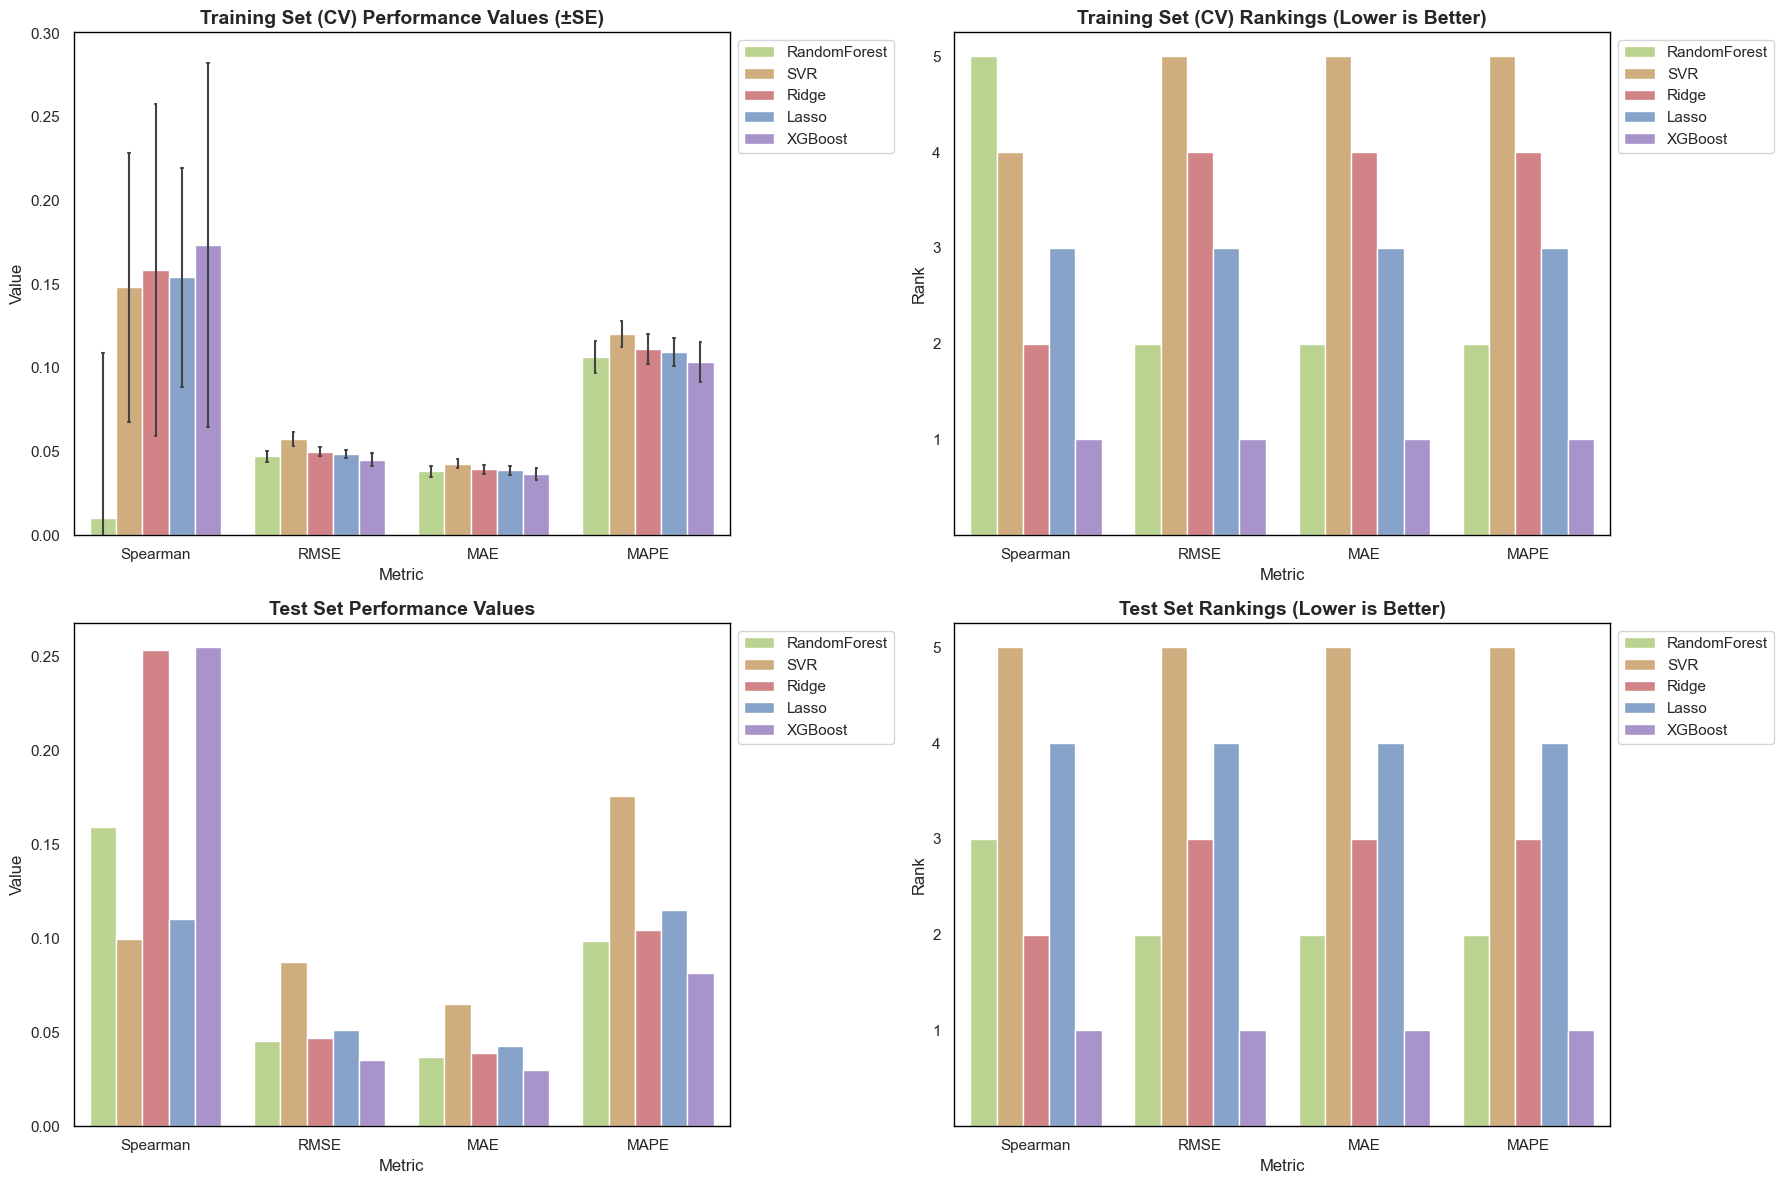

In [13]:
MODEL_ORDER = list(models.keys())
COLORS = ["#bdde85", "#ddaf70", "#de767c", "#7da1d5", "#a58bd4"]


def to_rank_df(df):
    ranked = df.copy()
    ranked["Spearman"] = ranked["Spearman"].rank(ascending=False)
    for col in ["RMSE", "MAE", "MAPE"]:
        ranked[col] = ranked[col].rank(ascending=True)
    return (
        ranked.reset_index()
        .rename(columns={"index": "Model"})
        .melt(id_vars="Model", var_name="Metric", value_name="Rank")
    )


def to_value_df(df):
    return (
        df.reset_index()
        .rename(columns={"index": "Model"})
        .melt(id_vars="Model", var_name="Metric", value_name="Value")
    )


bar_kw = dict(order=METRIC_ORDER, hue_order=MODEL_ORDER, palette=COLORS)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(
    data=df_cv_folds, x="Metric", y="Value", hue="Model",
    errorbar="se", capsize=0.05, err_kws={"linewidth": 1.5},
    ax=axes[0, 0], **bar_kw,
)
axes[0, 0].set_title("Training Set (CV) Performance Values (±SE)", fontsize=14, fontweight="bold")

sns.barplot(
    data=to_rank_df(df_cv_mean), x="Metric", y="Rank", hue="Model",
    ax=axes[0, 1], **bar_kw,
)
axes[0, 1].set_title("Training Set (CV) Rankings (Lower is Better)", fontsize=14, fontweight="bold")
axes[0, 1].set_yticks(range(1, len(models) + 1))

sns.barplot(
    data=to_value_df(df_test), x="Metric", y="Value", hue="Model",
    ax=axes[1, 0], **bar_kw,
)
axes[1, 0].set_title("Test Set Performance Values", fontsize=14, fontweight="bold")

sns.barplot(
    data=to_rank_df(df_test), x="Metric", y="Rank", hue="Model",
    ax=axes[1, 1], **bar_kw,
)
axes[1, 1].set_title("Test Set Rankings (Lower is Better)", fontsize=14, fontweight="bold")
axes[1, 1].set_yticks(range(1, len(models) + 1))

for ax in axes.flatten():
    ax.set_ylim(bottom=0)
    ax.grid(False)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(1)

plt.tight_layout()
plt.savefig("model_performance_comparison.pdf", format="pdf", bbox_inches="tight")
plt.show()

# 9. SHAP Analysis — Global Feature Importance

  0%|          | 0/97 [00:00<?, ?it/s]

Top 10 Positive Features (Promoters):


,Feature,Importance,Direction
23,C_S,0.003705,0.659581
78,N_N,0.002853,0.646039
24,C_T,0.002612,0.252328
18,C_K,0.001478,0.681175
107,T_C,0.001254,0.302469
117,T_S,0.001141,0.585083
46,G_S,0.001085,0.719727
76,N_C,0.001036,0.512144
132,Y_K,0.000916,0.924576
102,S_S,0.000911,0.683549



Top 10 Negative Features (Inhibitors):


,Feature,Importance,Direction
79,N_S,0.004347,-0.757881
115,T_N,0.004264,-0.118216
75,N_A,0.003244,-0.813504
47,G_T,0.001415,-0.727488
125,V_N,0.001308,-0.689356
150,V29_V41,0.001263,-0.780989
63,K_N,0.001138,-0.866558
192,S4_I17,0.001053,-0.856772
103,S_T,0.001022,-0.639745
110,T_G,0.000986,-0.727341


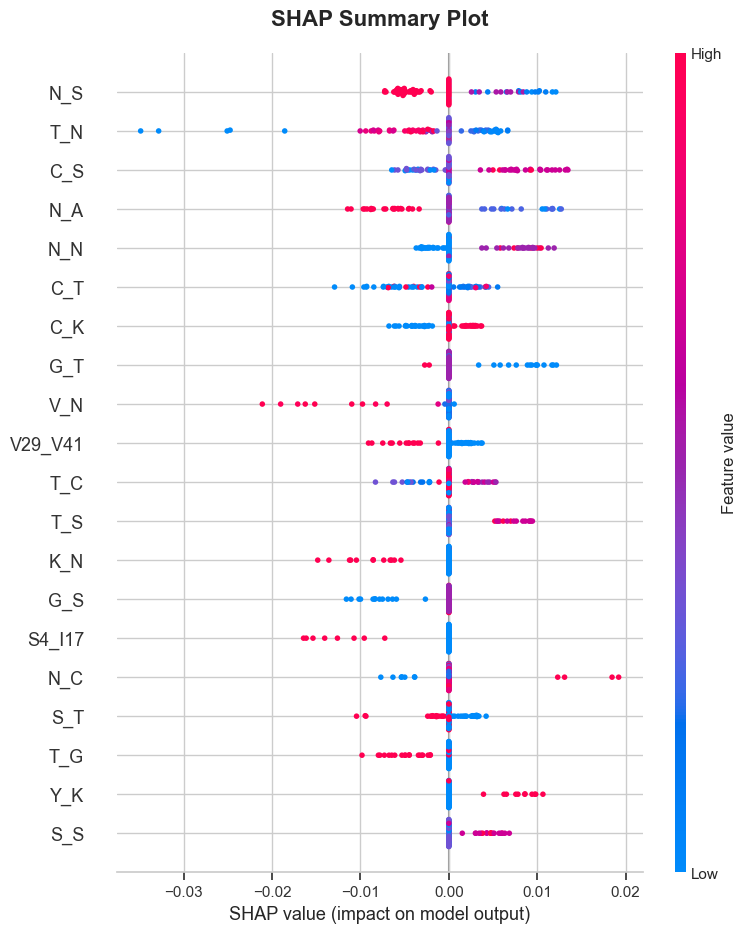

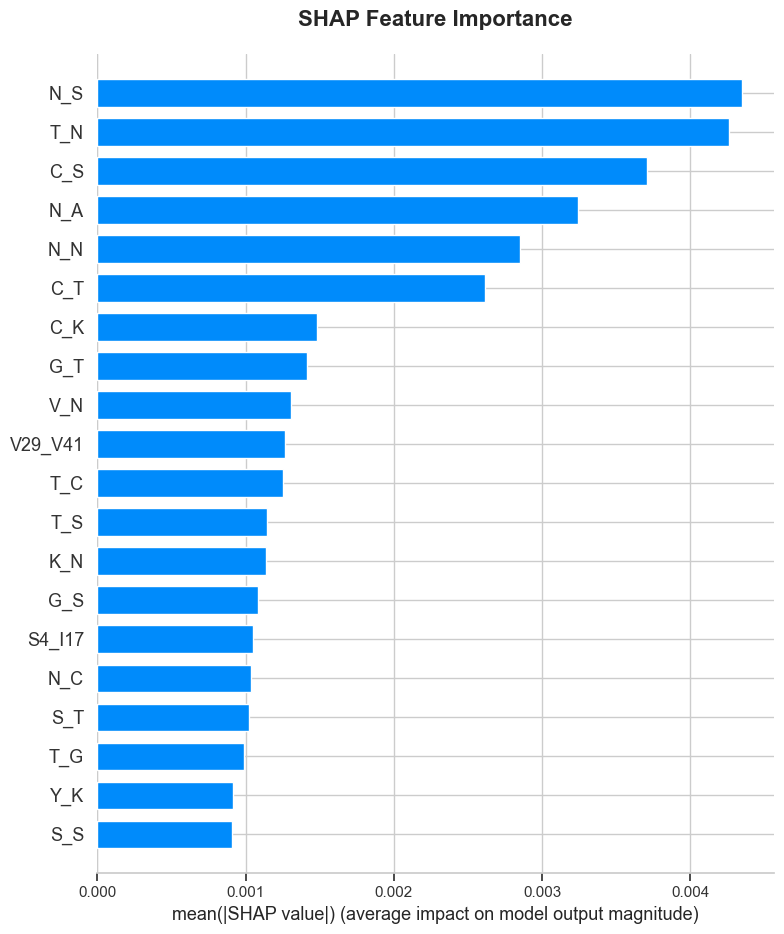

In [9]:
final_xgb = xgb.XGBRegressor(
    objective="reg:squarederror", random_state=666, n_jobs=-1, **xgb_params
)
final_xgb.fit(X_train_full, y_train_full)

explainer = shap.KernelExplainer(final_xgb.predict, shap.kmeans(X_train_full, 10))
shap_values = explainer.shap_values(X_train_full)

# Feature importance with directionality
importance_records = []
for i, name in enumerate(feature_names):
    feat_vals, shap_vals = X_train_full[:, i], shap_values[:, i]
    importance = np.mean(np.abs(shap_vals))
    if np.std(feat_vals) == 0 or np.std(shap_vals) == 0:
        corr = 0.0
    else:
        corr = np.corrcoef(feat_vals, shap_vals)[0, 1]
    importance_records.append({"Feature": name, "Importance": importance, "Direction": corr})

df_shap = pd.DataFrame(importance_records).sort_values("Importance", ascending=False)

print("Top 10 Positive Features (Promoters):")
display(df_shap[df_shap["Direction"] > 0].head(10))
print("\nTop 10 Negative Features (Inhibitors):")
display(df_shap[df_shap["Direction"] < 0].head(10))

plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_train_full, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_train_full, feature_names=feature_names, plot_type="bar", show=False)
plt.title("SHAP Feature Importance", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

# 10. Categorized SHAP — Top 5 per Feature Type


Top 5 — Global 2-mers:


,Feature,Importance,Direction
79,N_S,0.004347,-0.757881
115,T_N,0.004264,-0.118216
23,C_S,0.003705,0.659581
75,N_A,0.003244,-0.813504
78,N_N,0.002853,0.646039


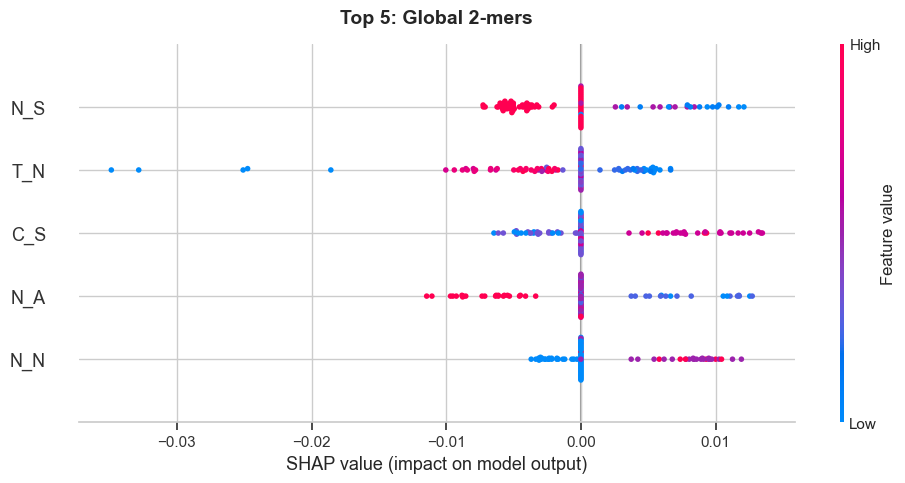


Top 5 — Positional 2-mers:


,Feature,Importance,Direction
150,V29_V41,0.001263,-0.780989
192,S4_I17,0.001053,-0.856772
139,T17_N29,0.000727,-0.990071
194,S4_V17,0.000592,0.624731
163,T53_T65,0.000467,-0.595035


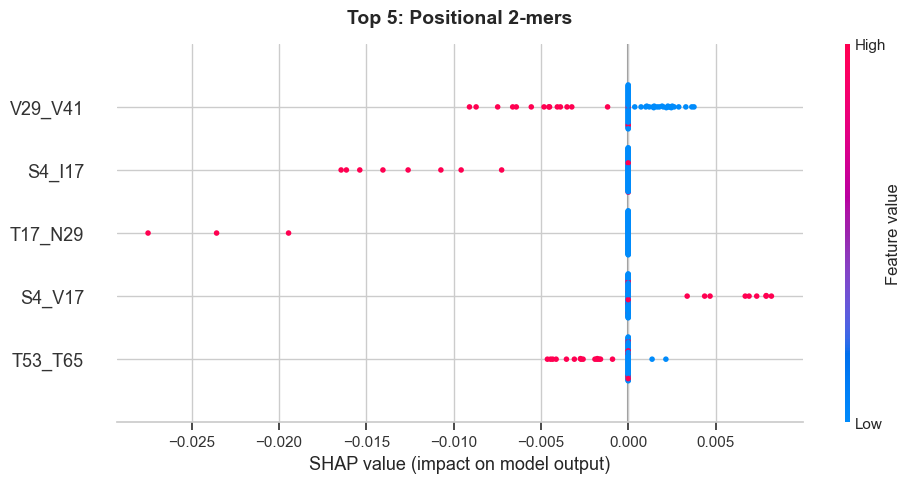

In [10]:
is_positional = df_shap["Feature"].str.contains(r"\d", regex=True)

categories = {
    "Global 2-mers": df_shap[~is_positional],
    "Positional 2-mers": df_shap[is_positional],
}

for cat_name, cat_df in categories.items():
    if cat_df.empty:
        continue

    top5 = cat_df.head(5)
    print(f"\nTop 5 — {cat_name}:")
    display(top5[["Feature", "Importance", "Direction"]])

    idx = [feature_names.index(f) for f in top5["Feature"]]
    plt.figure(figsize=(10, 5))
    shap.summary_plot(
        shap_values[:, idx], X_train_full[:, idx],
        feature_names=top5["Feature"].tolist(), show=False, plot_size=None,
    )
    plt.title(f"Top 5: {cat_name}", fontsize=14, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()